<p> <center><img src="img.jpg" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#AAD">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Analyse exploratoire détaillée </h2></center>
<hr style="border-width:2px;border-color:#AAD">

# I - Récupération des données précédentes

Nous commencons par importer les librairies nécessaires pour manipuler nos données :


In [1]:
# Gestion des chemins
from pathlib import Path

# Jeux de données
import pandas as pd
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Statistiques
import statsmodels.api as sm
from statsmodels.regression.linear_model import RegressionResults
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# Préprocessing
from sklearn.preprocessing import StandardScaler


Puis on récupère les données collectées aux étapes précédentes :

In [2]:
# Répertoire des données d'entrée
input_path = Path("../data/local_data/input/")

# Répertoire des données résultats intermédiaires
temp_path = Path("../data/local_data/temp/")

# Répertoire des données de sortie
output_path = Path("../data/local_data/output/")

# Chemin du dataset de production
input_datasets = output_path / 'region_2020_2025.csv'


On charge le jeu de données **region_2020_2025.csv** contenant l'ensemble des données précédemment collectées :
- les données de production issues d'**éCO2mix** ;
- les données astronomiques calculées concernant la position du soleil avec **PySolar** ;
- les données athmosphériques issues de **CAMS** (Copernicus Atmosphere Monitoring Service) ; et
- les données météorologiques issues de **NASA POWER**.  

Les données que nous avions collectées au niveau des cinq points d'intérêt ont été préalablement aggrégées car elles présentaient trop de corrélation entre elles.


In [3]:
# On récupère le dataset raw_2020_2025.csv
df = pd.read_csv(
    input_datasets, 
    index_col='datetime_utc', 
    parse_dates=True)


On se donne une date de fin de période pour l'entrainement :

In [4]:
end_train = '2023-12-31'

# II - Exploration préliminaire

Nous allons maintenant réaliser une première exploration de notre jeu de données afin de :
- visualiser les premières lignes du jeu de données,
- examiner les types de variables et les valeurs manquantes.


In [5]:
# Affichage du début et de la fin du jeu de données
display(df)


,consommation,region_altitude,region_azimuth,region_bhi,region_bni,region_clear_sky_bhi,region_clear_sky_bni,region_clear_sky_dhi,region_clear_sky_ghi,region_dhi,...,region_humidite,region_nebulosite,region_reliability,region_temperature,region_toa,region_vitesse_vent,solaire,target,tch_solaire,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,-67.658747,334.860133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,85.29220,23.86520,1.0,3.23070,0.0,1.34110,0.0,0.0,0.0,0.0
2019-12-31 23:30:00+00:00,5907.0,-69.154695,353.234530,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,83.15510,24.55650,1.0,3.38585,0.0,1.36150,0.0,0.0,0.0,0.0
2020-01-01 00:00:00+00:00,5724.0,-68.877374,12.560776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,81.01800,25.24780,1.0,3.54100,0.0,1.38190,0.0,0.0,0.0,0.0
2020-01-01 00:30:00+00:00,5749.0,-66.891776,30.183447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,79.06970,15.23310,1.0,3.60800,0.0,1.33655,0.0,0.0,0.0,0.0
2020-01-01 01:00:00+00:00,5700.0,-63.589084,44.705668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,77.12140,5.21840,1.0,3.67500,0.0,1.29120,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,-56.223103,297.107647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,71.31415,36.40500,1.0,1.24320,0.0,3.31620,0.0,0.0,0.0,0.0
2025-12-30 22:00:00+00:00,5837.0,-60.811889,306.996098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,70.98610,37.02250,1.0,1.09590,0.0,3.27060,0.0,0.0,0.0,0.0
2025-12-30 22:30:00+00:00,6056.0,-64.763196,319.404019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,71.32730,36.08765,1.0,0.96695,0.0,3.15875,0.0,0.0,0.0,0.0


Le jeu de données comprend 105 170 lignes et 21 colonnes. Les données sont collectées avec une résolution temporelle de **30 minutes** entre la dernière heure UTC du 31 décembre 2019 (`1er janvier 2020` heure française) et le `30 décembre 2025` (date de fin de service du satellite ayant collecté les données de nébulosité).

In [6]:
# Informations générales sur la structure des données
df.info()

print("\nNombre de valeur manquante :", df.isna().sum().sum())
print("Nombre de doublons :", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105170 entries, 2019-12-31 23:00:00+00:00 to 2025-12-30 23:30:00+00:00
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   consommation          105170 non-null  float64
 1   region_altitude       105170 non-null  float64
 2   region_azimuth        105170 non-null  float64
 3   region_bhi            105170 non-null  float64
 4   region_bni            105170 non-null  float64
 5   region_clear_sky_bhi  105170 non-null  float64
 6   region_clear_sky_bni  105170 non-null  float64
 7   region_clear_sky_dhi  105170 non-null  float64
 8   region_clear_sky_ghi  105170 non-null  float64
 9   region_dhi            105170 non-null  float64
 10  region_ghi            105170 non-null  float64
 11  region_humidite       105170 non-null  float64
 12  region_nebulosite     105170 non-null  float64
 13  region_reliability    105170 non-null  float64
 14  region

Il n'y a **aucune valeur manquante** et toutes les données sont **numériques**, à l'exception de l'index au format `DatetimeIndex`.

- **`consommation`** : consommation électrique totale du périmètre considéré sur l'intervalle de temps donné.
- **`datetime_utc`** : horodatage en temps universel coordonné (UTC) correspondant à l'instant d'agrégation des données (résolution 30 minutes).
- **`solaire`** : production électrique issue des installations photovoltaïques sur le périmètre considéré.
- **`target`** : variabilité du taux de charge de la production solaire à t + 30 minutes (notre variable cible).
- **`tco_solaire`** : taux de couverture de la production solaire.
- **`tch_solaire`** : taux de charge de la production solaire.
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit). 
- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).    
- **`bhi`** *(Beam Horizontal Irradiance)* : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).
- **`bni`** *(Beam Normal Irradiance)* : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²). 
- **`clear_sky_bhi`** : composante directe horizontale en conditions de ciel clair (Wh/m²).   
- **`clear_sky_bni`** : irradiance directe normale en conditions de ciel clair (Wh/m²).
- **`clear_sky_dhi`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²). 
- **`clear_sky_ghi`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²). 
- **`dhi`** *(Diffuse Horizontal Irradiance)* : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).     
- **`ghi`** *(Global Horizontal Irradiance)* : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².   
- **`humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).
- **`nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).   
- **`reliability`** : fiabilité des données CAMS (bhi, bni, clear_sky_bhi, clear_sky_bni, clear_sky_dhi, clear_sky_ghi, dhi, ghi, toa).
- **`temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).    
- **`toa`** *(Top Of Atmosphere)* : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.
- **`vitesse_vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  

In [7]:
# Informations statistiques générales
display(df.describe())


,consommation,region_altitude,region_azimuth,region_bhi,region_bni,region_clear_sky_bhi,region_clear_sky_bni,region_clear_sky_dhi,region_clear_sky_ghi,region_dhi,...,region_humidite,region_nebulosite,region_reliability,region_temperature,region_toa,region_vitesse_vent,solaire,target,tch_solaire,tco_solaire
count,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,...,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000
mean,4472.479405,0.342442,180.261128,63.695099,117.963388,89.202855,166.233043,23.809474,113.012329,30.095945,...,68.676157,51.102065,0.978336,14.401564,156.257087,2.687622,319.292536,2.393873,16.578480,7.081328
std,839.410834,34.209839,101.041300,104.646571,159.731755,124.410592,187.241797,30.327126,150.410731,42.190804,...,20.355860,34.211995,0.083532,8.475625,197.665300,1.511006,466.429135,3.249944,23.562155,10.398950
min,2620.000000,-69.612807,1.065672,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.017300,0.054200,0.500000,-4.733200,0.000000,0.164400,0.000000,0.000000,0.000000,0.000000
25%,3851.000000,-25.754906,90.421958,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,53.323975,18.299587,1.000000,7.657550,0.000000,1.457812,0.000000,0.000000,0.000000,0.000000
50%,4373.000000,0.580092,179.780724,0.041539,0.372436,0.390284,9.140822,1.951463,2.464659,1.620662,...,72.045750,47.118500,1.000000,13.474800,8.362237,2.420550,4.000000,0.310000,0.220000,0.090000
75%,5033.000000,26.441409,270.698881,96.273762,247.707725,168.130962,371.921211,44.130255,215.830080,50.597442,...,85.716525,86.663000,1.000000,20.368500,304.146134,3.568800,585.000000,4.290000,31.740000,12.810000
max,8044.000000,69.562549,358.763443,463.812108,509.467994,463.812108,510.283201,221.661441,504.713572,258.522808,...,100.000000,100.000000,1.000000,39.457900,617.546796,10.552600,2108.000000,24.970000,91.350000,51.490000


# III - Exploration des variables explicatives

## A - Variables explicatives collectées au niveau régional


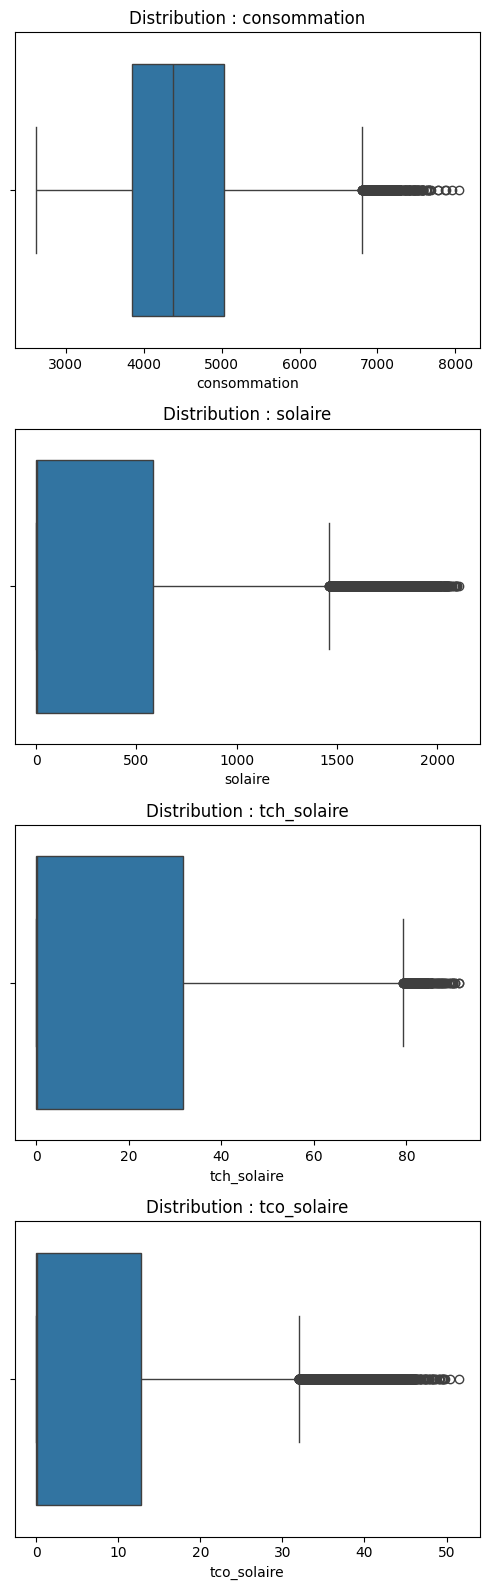

In [8]:
# Sélection des variables régionales à analyser
cols = [v for v in df.columns if (v[:7]!='region_' and v!='target')]

fig, axes = plt.subplots(len(cols), 1, figsize=(5, 4 * len(cols)))

for ax, col in zip(axes, cols):
    sns.boxplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution : {col}")

plt.tight_layout()
plt.show()


## B - Variables explicatives collectées au niveau communal

Afin d’explorer la distribution des variables météorologiques régionales construites par agrégation pondérée, une analyse exploratoire est réalisée à l’aide de boxplots.

L’analyse est restreinte aux instants où l’irradiation globale régionale (GHI_region) est significative (supérieure à 5), afin d’exclure les périodes nocturnes ou non pertinentes d’un point de vue énergétique.


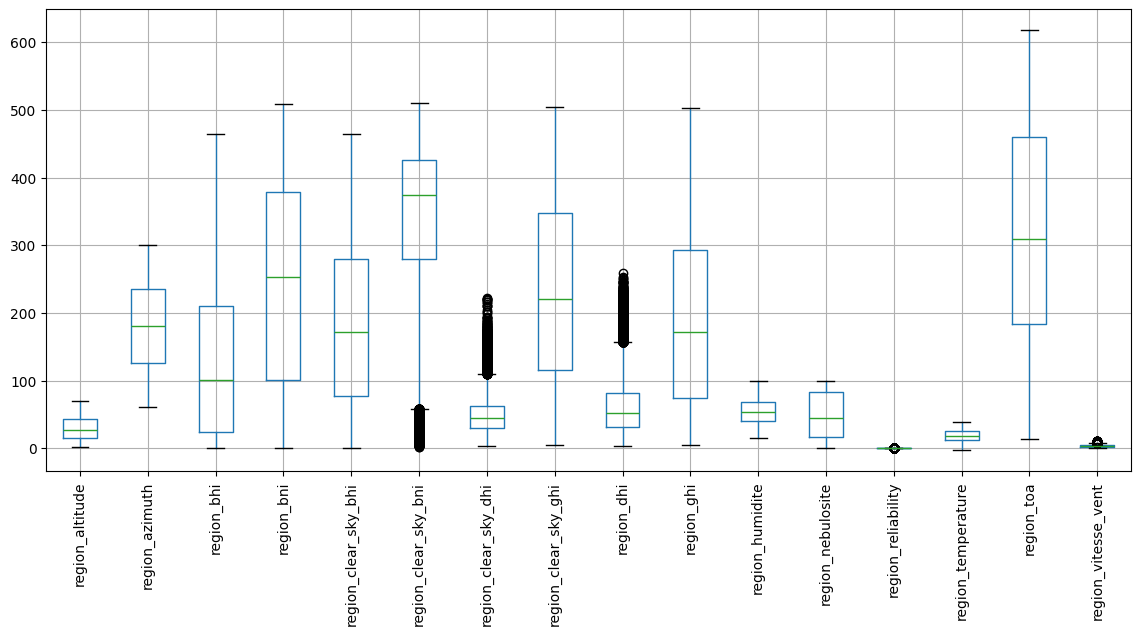

In [9]:
# Sélection des variables régionales à analyser
region_vars = [v for v in df.columns if (v[:7]=='region_')]

# Filtrage des observations :
# on conserve uniquement les pas de temps où l'irradiation globale
# régionale est significative (GHI_region > 5)
df_filtered = df.loc[df["region_ghi"] > 5, region_vars]

# Visualisation exploratoire des distributions
# à l'aide de boxplots pour comparer les variables régionales
df_filtered.boxplot(rot=90, figsize=(14, 6));


In [10]:
df_train = df[:end_train]

# Trouver les variables explicatives qui ont une variance inférieure à 0.01
sel = VarianceThreshold(threshold=0.01)
sel.fit(df_train)

# Afficher les variables concernées
mask = sel.get_support()
print("Variables de faible variance :", df_train.columns[~mask])


Variables de faible variance : Index(['region_reliability'], dtype='object')


# IV - Analyse de la variabilité du TCH

## A - Définition de TCH
Le **TCH (Taux de Charge ou Facteur de Charge)** mesure l'utilisation réelle d'une capacité de production électrique par rapport à ce qu'elle pourrait produire à plein régime.  
Il se calcule ainsi :

$$
\text{TCH} = \frac{\text{Production réelle}}{\text{Capacité installée}}
$$

## B - Variabilité
La **variabilité** nous indique **à quel point la production réelle fluctue autour de la moyenne** :

- Une production stable → faible variabilité.  
- Une production irrégulière → forte variabilité.

Pour comparer des périodes avec des moyennes différentes, on utilise le **coefficient de variation (CV)** :

$$
\text{CV} = \frac{\text{Écart-type } (\sigma)}{\text{Moyenne }(\mu)}
$$

- CV élevé → forte variabilité de la production par rapport à la moyenne..  
- CV faible → faible variabilité, indiquant une production plus régulière par rapport à la moyenne.  


## C - Méthodes utilisées

### 1 - **Statistiques horaires** : 

In [11]:
# df_day = df[df["hour"].between(4,19)]
df_day = df.loc[df.region_ghi > 0]
df_day['hour'] = df_day.index.hour

# Calculer les statistiques horaires pour la production solaire
hour_stats = df_day.groupby('hour')['tch_solaire'].describe() 

# Ajouter le coefficient de variation
hour_stats['cv'] = hour_stats['std'] / hour_stats['mean']

display(hour_stats)


/tmp/ipykernel_9756/4288002606.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['hour'] = df_day.index.hour


,count,mean,std,min,25%,50%,75%,max,cv
hour,,,,,,,,,
4,1103.0,0.232529,0.356519,0.00,0.0000,0.000,0.4000,1.98,1.533219
5,2201.0,2.409060,2.409581,0.00,0.2200,1.740,3.8000,9.58,1.000217
6,3203.0,8.382869,7.358798,0.00,1.2300,7.170,13.8650,27.17,0.877838
7,4382.0,16.599651,14.188487,0.00,2.0900,14.510,29.1200,49.16,0.854746
8,4382.0,30.277707,18.163218,0.22,12.8925,31.500,46.5175,66.62,0.599888
9,4382.0,42.572827,19.389726,0.82,26.8125,45.690,59.5700,80.85,0.455448
10,4382.0,50.569247,19.665360,1.64,37.3225,54.060,67.2100,88.38,0.388880
11,4382.0,53.841570,19.546221,2.56,41.7725,57.345,70.2300,91.35,0.363032
12,4382.0,53.103656,19.368453,2.25,41.1200,56.350,69.4075,91.30,0.364729


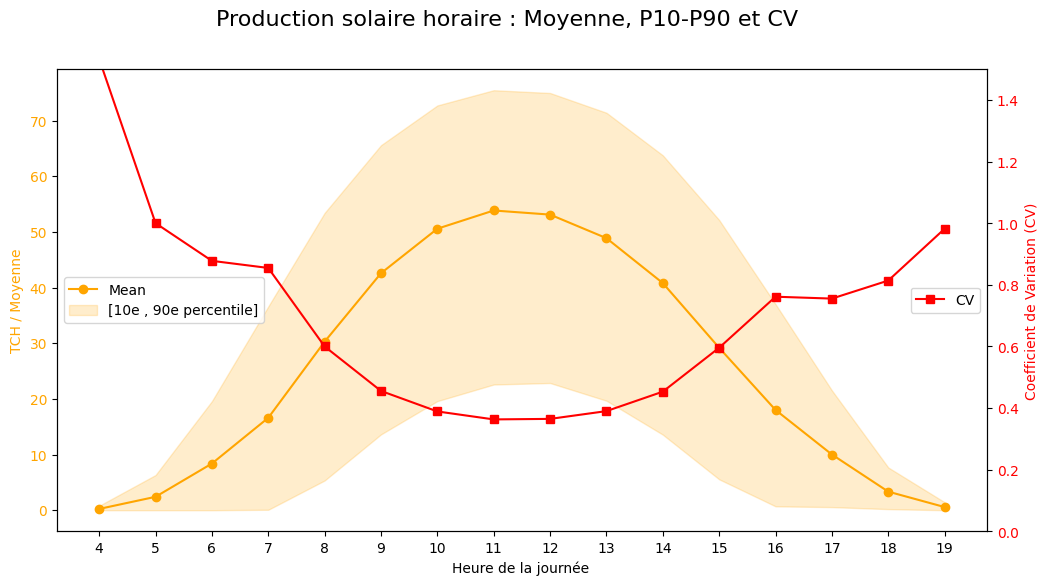

In [12]:
heures = hour_stats.index
mean = hour_stats['mean']
std = hour_stats['std']
cv = hour_stats['cv']

# Calcul des percentiles
p10 = hour_stats['p10'] = df_day.groupby('hour')['tch_solaire'].quantile(0.10)
p90 = hour_stats['p90'] = df_day.groupby('hour')['tch_solaire'].quantile(0.90)

# Figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe moyenne + bande
ax1.plot(heures, mean, marker='o', color='orange', label='Mean')
ax1.fill_between(heures, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Heure de la journée ')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticks(heures)

# CV sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(heures, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de Variation (CV)', color='red')
ax2.set_ylim(0, 1.5)
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Production solaire horaire : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='center left')
ax2.legend(loc='center right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque heure de la journée :  
- la **moyenne de la production solaire** (`mean`) en orange ;  
- la **bande** (zone orange claire) représentant la **dispersion absolue** autour de la moyenne (écart-type) ;  
- le **coefficient de variation (CV)** (courbe rouge sur l'axe secondaire), qui indique la **variabilité relative par rapport à la moyenne**.


**Observations**

1. **Variabilité absolue**
    - La bande est **très étroite tôt le matin (4–5h) et en soirée (18–19h)** : la production est faible et la dispersion absolue reste limitée.
    - Elle devient **très large entre 6h et 12h**, lorsque la production solaire augmente fortement et varie davantage d'un jour à l'autre.
    - L'après-midi (13–17h), la bande **se resserre progressivement** à mesure que la production moyenne diminue.


2. **Variabilité relative (CV)**
    - Le **CV est minimal autour de midi (≈ 0,36–0,39 entre 10h et 13h)** : la production est élevée et **relativement stable par rapport à sa moyenne**.
    - Le **CV est élevé tôt le matin (≈ 0,76–0,98 entre 4h et 7h)** et en fin de journée (**≈ 0,55–0,72 entre 15h et 18h**) : la production est plus faible et les fluctuations représentent une **part importante de la moyenne**.


3. **La variabilité ne suit pas le niveau moyen**
    - Les heures avec une **faible moyenne** (tôt le matin, fin de journée) présentent souvent un **CV élevé**, car une variation modérée en valeur absolue représente une grande part de la moyenne.
    - Les heures avec une **moyenne élevée** (≈ 8h–15h) ont un **CV plus faible**, même si l'écart-type absolu est important : la production est alors **plus stable proportionnellement**.


**Conclusion**
- La production solaire est **faible et relativement instable en proportion** en début et fin de journée (CV élevé).
- Elle est **maximale et la plus régulière autour de midi**, caractérisée par une **forte moyenne et un faible CV**.

Cette analyse permet d'identifier les **heures les plus stables** (milieu de journée) et celles où la **variabilité relative est la plus forte** (matin et fin d'après-midi).


### 2 - **Statistiques mensuelles** :

In [13]:
# Calcul des statistiques de base
df_day['month'] = df_day.index.month

monthly_stats = df_day.groupby('month')['tch_solaire'].describe()

# Calcul du coefficient de variation
monthly_stats['cv'] = monthly_stats['std'] / monthly_stats['mean']

monthly_stats


/tmp/ipykernel_9756/3747682742.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['month'] = df_day.index.month


,count,mean,std,min,25%,50%,75%,max,cv
month,,,,,,,,,
1,3669.0,21.740534,18.067194,0.0,5.0100,18.080,37.0500,63.82,0.831037
2,3715.0,27.675545,21.740561,0.0,7.2400,24.030,46.7550,73.50,0.785551
3,4622.0,31.507460,23.652953,0.0,8.5475,29.980,52.0425,81.16,0.750710
4,5003.0,33.892023,25.183196,0.0,9.6800,32.590,55.7200,84.57,0.743042
5,5643.0,33.990748,25.121895,0.0,9.3550,32.920,56.1000,87.81,0.739080
6,5704.0,34.397598,24.839404,0.0,9.1650,34.665,55.9000,82.25,0.722126
7,5765.0,38.363490,26.505411,0.0,10.8400,41.830,62.9800,86.99,0.690902
8,5349.0,38.626904,26.628492,0.0,12.0800,41.260,63.0800,91.35,0.689377
9,4659.0,33.981314,24.266430,0.0,10.2800,33.810,55.9600,82.78,0.714111


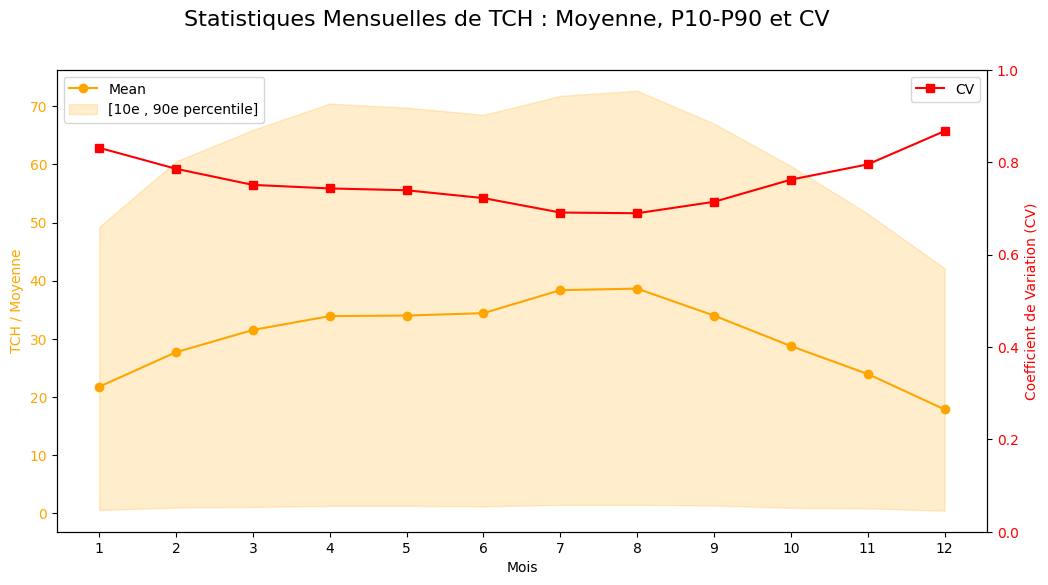

In [14]:
mois = monthly_stats.index
mean = monthly_stats['mean']
std = monthly_stats['std']
cv = monthly_stats['cv']

# Calcul des percentiles
p10 = monthly_stats['p10'] = df_day.groupby('month')['tch_solaire'].quantile(0.10)
p90 = monthly_stats['p90'] = df_day.groupby('month')['tch_solaire'].quantile(0.90)

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Tracer mean et std sur le même axe
ax1.plot(mois, mean, marker='o', color='orange', label='Mean')
ax1.fill_between(mois, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Mois')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xticks(mois)

# Tracer CV sur un axe secondaire
ax2 = ax1.twinx()
ax2.plot(mois, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de Variation (CV)', color='red')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Statistiques Mensuelles de TCH : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque mois :  
- la **moyenne du TCH** (courbe orange) ;  
- la **bande** (zone orange claire) représentant la **dispersion absolue** autour de la moyenne (écart-type) ;  
- le **coefficient de variation (CV)** (courbe rouge sur l'axe secondaire), qui mesure la **variabilité relative par rapport à la moyenne**.


**Observations**

1. **Variabilité absolue (bande)**
    - La bande est **plus large entre juin et août**, indiquant un **écart-type absolu élevé**, lié à des niveaux de production plus importants.
    - Elle est **plus étroite en hiver (décembre–janvier)**, lorsque la production moyenne est plus faible en valeur absolue.


2. **Variabilité relative (CV)**
    - Le **CV est le plus élevé en hiver**, notamment en **décembre (≈ 0,78)** et **janvier (≈ 0,76)** :  
  la production est faible et les fluctuations représentent une **grande part de la moyenne**.
    - Le **CV diminue progressivement vers l'été**, avec un minimum en **juillet–août (≈ 0,64–0,65)** :  
  la production est plus **stable proportionnellement**, même si elle reste variable en valeur absolue.
    - À l'automne (septembre–novembre), le CV **remonte progressivement**, traduisant une variabilité relative croissante à mesure que la production moyenne diminue.


3. **La variabilité ne suit pas le niveau moyen**
    - Les mois à **forte moyenne** (été) peuvent présenter une **dispersion absolue importante**, mais un **CV faible**, ce qui indique une production relativement régulière.
    - À l'inverse, les mois à **faible moyenne** (hiver) ont un **CV élevé**, car des variations modérées en valeur absolue deviennent importantes **en proportion de la moyenne**.


**Conclusion**
- Le TCH est **proportionnellement plus instable en hiver**, malgré des niveaux de production plus faibles.
- En été, la production est **plus régulière relativement à son niveau moyen**, même si les fluctuations absolues sont importantes.
- Le coefficient de variation permet ainsi de **comparer correctement les mois entre eux**, indépendamment des différences de niveau moyen, et d'identifier les périodes **les plus stables et les plus variables**.


### 3 - **Statistiques saisonnières** :
En plus de l'échelle mensuelle, il est souvent plus parlant de raisonner en **saisons** :

- **Hiver** : période à faible hauteur solaire, jours courts, météo plus perturbée  
- **Printemps** : transition vers des jours plus longs et une irradiance croissante  
- **Été** : hauteur solaire maximale, forte irradiance, durée du jour maximale  
- **Automne** : retour à des conditions plus instables et jours plus courts

On définit une fonction `saison(row)` qui attribue une saison à chaque date en fonction du mois et du jour, en se basant sur les dates officielles de début des saisons.

Ces saisons servent ensuite à :

- calculer des **statistiques de TCH par saison**,  
- comparer la **stabilité relative** de la production solaire d'une saison à l'autre via le **coefficient de variation (CV)**.

In [15]:
# Fonction pour déterminer la saison 
def saison(row):
    mois = row['month']
    jour = row['day']

    if (mois == 12 and jour >= 21) or (mois <= 2) or (mois == 3 and jour < 21):
        return "Hiver"
    elif (mois == 3 and jour >= 21) or (mois in [4,5]) or (mois == 6 and jour < 21):
        return "Printemps"
    elif (mois == 6 and jour >= 21) or (mois in [7,8]) or (mois == 9 and jour < 21):
        return "Été"
    else:  
        return "Automne"

df_day['day'] = df_day.index.day
df_day['saison'] = df_day.apply(saison, axis=1)


/tmp/ipykernel_9756/292980926.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['day'] = df_day.index.day
/tmp/ipykernel_9756/292980926.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['saison'] = df_day.apply(saison, axis=1)


In [16]:
# Calculer les statistiques par saison pour la production solaire
season_stats = df_day.groupby('saison')['tch_solaire'].describe()

# Ajouter le coefficient de variation
season_stats['cv'] = season_stats['std'] / season_stats['mean']

season_stats

,count,mean,std,min,25%,50%,75%,max,cv
saison,,,,,,,,,
Automne,11653.0,25.596610,20.721604,0.0,6.09,21.920,43.080,76.82,0.809545
Hiver,11525.0,25.570152,20.871787,0.0,6.20,21.660,42.650,76.50,0.816256
Printemps,16146.0,33.892191,24.992212,0.0,9.34,33.025,55.735,87.81,0.737403
Été,16193.0,37.248969,26.064885,0.0,11.07,39.270,61.170,91.35,0.699748


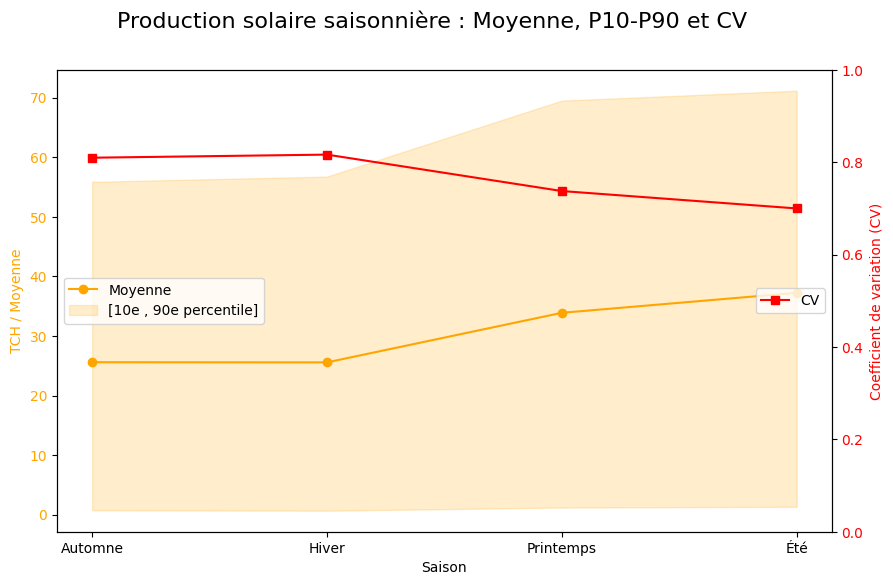

In [17]:
saisons = season_stats.index
mean = season_stats['mean']
std = season_stats['std']
cv = season_stats['cv']

# Calcul des percentiles
p10 = season_stats['p10'] = df_day.groupby('saison')['tch_solaire'].quantile(0.10)
p90 = season_stats['p90'] = df_day.groupby('saison')['tch_solaire'].quantile(0.90)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Courbe moyenne + bande [0, mean + std]
ax1.plot(saisons, mean, marker='o', color='orange', label='Moyenne')
ax1.fill_between(saisons, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('Saison')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

# CV sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(saisons, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de variation (CV)', color='red')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Production solaire saisonnière : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='center left')
ax2.legend(loc='center right')

plt.show()


**Interprétation du graphique**

Le graphique montre, pour chaque saison :  
- la **moyenne de la production solaire** (`mean`) en orange ;  
- la **bande** (zone orange claire) représentant la **dispersion absolue** autour de la moyenne (écart-type) ;  
- le **coefficient de variation (CV)** (courbe rouge sur l'axe secondaire), qui mesure la **variabilité relative par rapport à la moyenne**.

**Observations**

**1. Variabilité absolue**
    
- La **bande est plus large au printemps et en été** :  
  l'écart-type absolu est plus élevé car la production solaire est plus importante et varie davantage d'un jour à l'autre.
- La **bande est plus étroite en automne et en hiver** :  
  la production moyenne est plus faible, ce qui limite la dispersion absolue.


**2. Variabilité relative (CV)**

- Le **CV est le plus élevé en automne et en hiver (≈ 0,75)** :  
  les fluctuations représentent une part importante de la moyenne, indiquant une **production proportionnellement plus instable**.
- Le **CV diminue au printemps (≈ 0,70)** et atteint son minimum en **été (≈ 0,66)** :  
  la production est alors **plus régulière relativement à son niveau moyen**, malgré des variations absolues importantes.


**Conclusion**
- La production solaire est **proportionnellement plus stable au printemps et en été**, périodes de forte production.
- L'automne et l'hiver présentent une **production plus instable relativement à la moyenne**, bien que la dispersion absolue soit plus faible.
- Le coefficient de variation permet ainsi de **comparer les saisons indépendamment de leur niveau moyen** et de mieux identifier les périodes les plus régulières et les plus variables.


# V - Lien entre TCH solaire et les autres variables explicative

## A - Lien entre TCH et GHI régional

**GHI (Global Horizontal Irradiance)** désigne la quantité totale de rayonnement solaire reçue par une surface horizontale, incluant la composante directe et la composante diffuse.

Une fois `GHI_region` construite, l'objectif est d'analyser la sensibilité du TCH aux variations de l'irradiance globale régionale.  

On étudie comment le TCH évolue en fonction des hausses ou baisses du GHI afin de mettre en évidence une relation entre l'ensoleillement régional et le comportement du TCH.

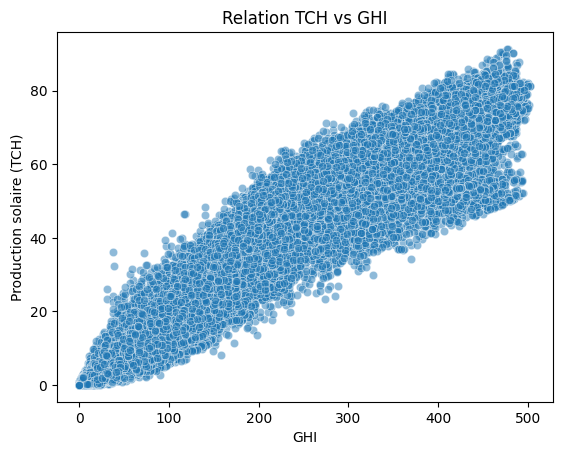

In [18]:
sns.scatterplot(x='region_ghi', y='tch_solaire', data=df_day, alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Production solaire (TCH)')
plt.title('Relation TCH vs GHI')
plt.show()


Afin d'évaluer l'existence et l'intensité d'un lien statistique entre le GHI régional et le TCH, on calcule deus coefficients de corrélation (corrélation de **Pearson** et corrélation de **Spearman**) ainsi que leurs p-values associées, permettant d'apprécier la significativité de la relation observée.

In [19]:
corr_p, p_value_p = pearsonr(df_day['region_ghi'], df_day['tch_solaire'])
corr_s, p_value_s = spearmanr(df_day['region_ghi'], df_day['tch_solaire'])
print(f"Corrélation Pearson : {corr_p}")
print(f"P-value : {p_value_p}")
print(f"Corrélation Spearman : {corr_s}")
print(f"P-value : {p_value_s}")


Corrélation Pearson : 0.9596794656493629
P-value : 0.0
Corrélation Spearman : 0.971020771819272
P-value : 0.0


Les résultats montrent une **corrélation très forte et positive** entre le GHI régional et le TCH.  
Les coefficients, proches de 1, indiquent que le TCH augmente fortement lorsque le GHI régional augmente.  
Les p-values nulles confirment que cette relation est **hautement significative statistiquement**.


### 1 - Statistiques descriptives en fonction des niveaux d'irradiance

Dans cette étape, la production TCH est étudiée en fonction de classes de GHI définies par intervalles réguliers. Pour chaque bin d'irradiance, des statistiques descriptives sont calculées, notamment la moyenne, l'écart-type, les percentiles P10 et P90, ainsi que le coefficient de variation (CV).

Cette approche permet comme avant de caractériser la relation entre l'intensité de l'irradiance et la production solaire selon trois dimensions complémentaires : le niveau moyen de production, la dispersion absolue autour de cette moyenne et la variabilité relative au sein de chaque régime d'irradiance. 


/tmp/ipykernel_9756/581267114.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['ghi_bin'] = pd.cut(df_day['region_ghi'], bins)
/tmp/ipykernel_9756/581267114.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ghi_stats = df_day.groupby('ghi_bin')['tch_solaire'].describe()
/tmp/ipykernel_9756/581267114.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ghi_st

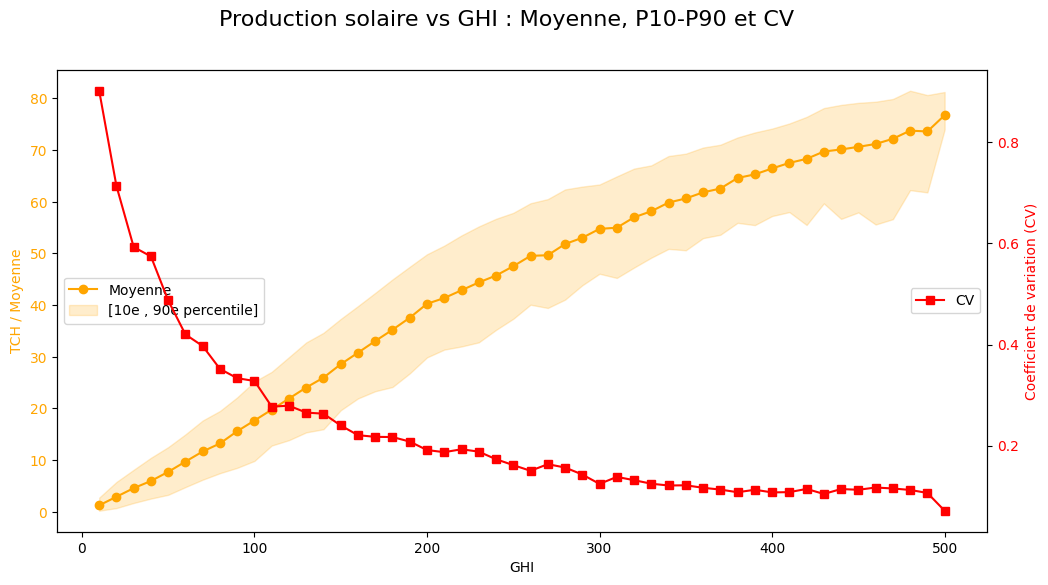

In [20]:
# Définir les bins
bins = range(5, int(df_day['region_ghi'].max()) + 50, 10)
df_day['ghi_bin'] = pd.cut(df_day['region_ghi'], bins)

# Stats par bin
ghi_stats = df_day.groupby('ghi_bin')['tch_solaire'].describe()
ghi_stats['cv'] = ghi_stats['std'] / ghi_stats['mean']

# Percentiles P10 et P90
ghi_stats['p10'] = df_day.groupby('ghi_bin')['tch_solaire'].quantile(0.10)
ghi_stats['p90'] = df_day.groupby('ghi_bin')['tch_solaire'].quantile(0.90)

# Convertir l'IntervalIndex en valeur numérique (milieu du bin)
ghi_stats['GHI_mid'] = ghi_stats.index.map(lambda x: x.mid)

# Variables pour le tracé
ghi = ghi_stats['GHI_mid']
mean = ghi_stats['mean']
cv = ghi_stats['cv']
p10 = ghi_stats['p10']
p90 = ghi_stats['p90']

# Tracé
fig, ax1 = plt.subplots(figsize=(12, 6))

# Courbe moyenne + bande P10-P90
ax1.plot(ghi, mean, marker='o', color='orange', label='Moyenne')
ax1.fill_between(ghi, p10, p90, color='orange', alpha=0.2, label='[10e , 90e percentile]')
ax1.set_xlabel('GHI')
ax1.set_ylabel('TCH / Moyenne', color='orange')
ax1.tick_params(axis='y', labelcolor='orange')

# CV sur axe secondaire
ax2 = ax1.twinx()
ax2.plot(ghi, cv, marker='s', color='red', label='CV')
ax2.set_ylabel('Coefficient de variation (CV)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Titres et légendes
fig.suptitle('Production solaire vs GHI : Moyenne, P10-P90 et CV', fontsize=16)
ax1.legend(loc='center left')
ax2.legend(loc='center right')

plt.show()


### 2 - **Interprétation du graphique GHI – TCH**

Le graphique présente, pour chaque classe de GHI, la moyenne de TCH, l'intervalle P10–P90 et le coefficient de variation (CV).

### 3 - **Principales observations**

1. La moyenne de TCH augmente régulièrement avec le GHI, ce qui traduit une relation cohérente entre irradiance et production.

2. La dispersion absolue (P10–P90) s'élargit avec le GHI. Aux faibles GHI, les valeurs restent concentrées à bas niveau. Aux GHI moyens et élevés, les valeurs sont plus étalées en valeur absolue autour de la moyenne.

3. Le CV est élevé aux faibles GHI, ce qui indique une variabilité relative importante pour une production moyenne faible. Le CV diminue progressivement lorsque le GHI augmente, la production devient alors plus stable proportionnellement à la moyenne.

### 4 - **Conclusion**

La production est faible et instable en proportion aux faibles irradiances, alors qu'elle devient élevée et relativement plus stable aux irradiances élevées. La variabilité absolue augmente avec la production, tandis que la variabilité relative diminue avec le GHI.


## B - Lien entre TCH et angles solaires

In [21]:
zenith_deg = 90.0 - df_day["region_altitude"]
zenith_rad = np.deg2rad(zenith_deg)
df_day["cos_zenith_region"] = np.cos(zenith_rad)

# Mettre 0 la nuit si altitude <= 0
df_day.loc[df_day["region_altitude"] <= 0, "cos_zenith_region"] = 0

/tmp/ipykernel_9756/171070975.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["cos_zenith_region"] = np.cos(zenith_rad)


### 1 - **Interprétation :**

- `cos_zenith_region` proche de 1 → soleil très haut (midi, été) → TCH potentiel max
- `cos_zenith_region` proche de 0 → soleil rasant / nuit → très peu de production possible
  
### 2 - **Calcul de l'angle d'incidence solaire sur les panneaux**

`cos_incidence` mesure l'angle entre la surface du panneau et la direction du soleil.

Formule trigonométrique pour un panneau incliné et orienté :

$$
\cos(\theta) = \sin(\alpha) \cdot \cos(\beta) + \cos(\alpha) \cdot \sin(\beta) \cdot \cos(\gamma_s - \gamma_p)
$$

- **$\alpha$** = altitude du soleil  
- **$\beta$** = inclinaison des panneaux par rapport à l'horizontale, en degrés  
- **$\gamma_s$** = azimut du soleil  
- **$\gamma_p$** = orientation (azimut) des panneaux, en degrés.  

**Interprétation :**

- `cos_incidence proche 1` → soleil perpendiculaire au panneau → production maximale  
- `cos_incidence proche 0` → soleil très oblique → peu de production  
- `cos_incidence < 0` → soleil derrière le panneau → pas de production


In [22]:
# Hypothèses
beta_deg = 30.0        # inclinaison des panneaux
gamma_p_deg = 180.0    # azimuth panneaux (Sud)

alpha_rad = np.deg2rad(df_day["region_altitude"])
gamma_s_rad = np.deg2rad(df_day["region_azimuth"])
beta_rad = np.deg2rad(beta_deg)
gamma_p_rad = np.deg2rad(gamma_p_deg)

df_day["cos_incidence_region"] = (
    np.sin(alpha_rad) * np.cos(beta_rad)
    + np.cos(alpha_rad) * np.sin(beta_rad) * np.cos(gamma_s_rad - gamma_p_rad)
)

# On met 0 la nuit ou quand le soleil est derrière les panneaux
df_day.loc[(df_day["region_altitude"] <= 0) | (df_day["cos_incidence_region"] < 0), "cos_incidence_region"] = 0


/tmp/ipykernel_9756/1103466848.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["cos_incidence_region"] = (


### 3 - **Corrélation entre angles solaires et production TCH**

In [23]:
print("Corr cos_zenith/TCH :", pearsonr(df_day["cos_zenith_region"], df_day["tch_solaire"]))
print("Corr cos_incidence/TCH :", pearsonr(df_day["cos_incidence_region"], df_day["tch_solaire"]))
print("Corr cos_zenith_region/cos_incidence_region :", pearsonr(df_day["cos_zenith_region"], df_day["cos_incidence_region"]))


Corr cos_zenith/TCH : PearsonRResult(statistic=0.8654194973994171, pvalue=0.0)
Corr cos_incidence/TCH : PearsonRResult(statistic=0.8224783748691198, pvalue=0.0)
Corr cos_zenith_region/cos_incidence_region : PearsonRResult(statistic=0.8675663311958798, pvalue=0.0)


### 4 - **Analyse des corrélations avec le TCH**

Les corrélations entre le TCH et les variables géométriques `cos_zenith_region` et `cos_incidence_region` sont très élevées. Cela confirme que la **position du soleil** dans le ciel (géométrie solaire) explique une part importante de la variabilité du TCH.

On observe que :  
- `cos_zenith_region` corrèle légèrement mieux avec le TCH que `cos_incidence_region`.  
- `cos_incidence_region` repose sur une **hypothèse d'orientation** moyenne des panneaux (inclinaison et azimuth).  
  Si cette hypothèse ne reflète pas fidèlement la réalité du parc photovoltaïque (orientations variées, installations Est/Ouest, toitures, etc.), cette variable devient moins représentative.  
- À l'inverse, `cos_zenith_region` dépend uniquement de la **hauteur du soleil** et reste valable quelles que soient les orientations réelles des installations.  

Par ailleurs, les deux variables `cos_zenith_region` et `cos_incidence_region` sont fortement corrélées entre elles, ce qui les rend presque **redondantes** d'un point de vue statistique.


**Conclusion:**
`cos_incidence_region` n'apporte pas d'information supplémentaire significative par rapport à cos_zenith_region.
Dans la suite de l'analyse, nous conservons donc **`cos_zenith_region` comme feature principale**.


## C - Lien entre TCH et nébulosité régionale

L'analyse précédente a montré comment la production TCH évolue en fonction du GHI, avec une augmentation de la moyenne et une diminution progressive de la variabilité relative lorsque l'irradiance augmente. Cependant, le GHI ne reflète pas uniquement l'intensité solaire ; il est également influencé par la présence et la dynamique des nuages.

Pour mieux comprendre le rôle spécifique de la couverture nuageuse dans la variabilité de la production, nous regroupons maintenant les données selon des **catégories de nébulosité** (clair, partiellement clair, nuageux, très nuageux) et observons la distribution de TCH au sein de chaque catégorie à l'aide d'un boxplot. Cette étape permet de distinguer les effets liés à la radiation solaire de ceux associés aux conditions atmosphériques et d'identifier plus précisément comment les nuages impactent la stabilité et l'amplitude de la production solaire.


/tmp/ipykernel_9756/1937128004.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['cloud_category'] = pd.cut(df_day['region_nebulosite'], bins=bins, labels=labels, include_lowest=True)


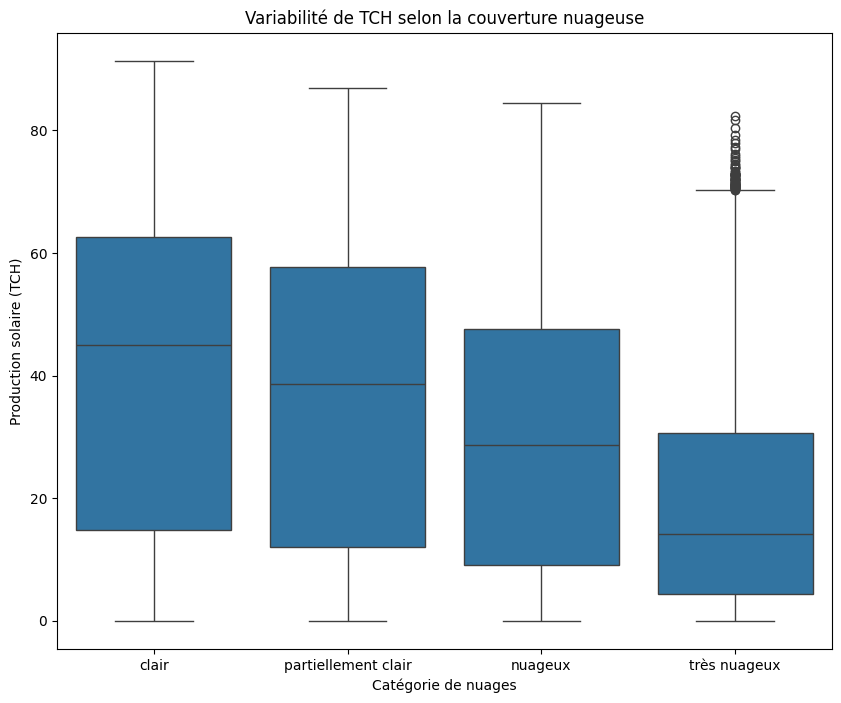

In [24]:
bins = [0, 20, 50, 80, 100]
labels = ['clair', 'partiellement clair', 'nuageux', 'très nuageux']
df_day['cloud_category'] = pd.cut(df_day['region_nebulosite'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,8))
sns.boxplot(x='cloud_category', y='tch_solaire', data=df_day)
plt.xlabel('Catégorie de nuages')
plt.ylabel('Production solaire (TCH)')
plt.title('Variabilité de TCH selon la couverture nuageuse')
plt.show()


Le boxplot montre la distribution de la production solaire (TCH) pour différentes catégories de couverture nuageuse. La médiane, la dispersion et les valeurs extrêmes permettent d'identifier l'impact des nuages sur le niveau et la variabilité de la production.

- **Clair**: Production moyenne élevée avec des valeurs maximales importantes. La dispersion en valeur absolue est large, ce qui correspond à un régime de production intense mais étendu.

- **Partiellement clair**: Production intermédiaire, avec une variabilité marquée liée à l'alternance entre ensoleillement et passages nuageux.

- **Nuageux**: Production plus faible et plus homogène, avec une dispersion resserrée autour de valeurs modérées.

- **Très nuageux**: Production basse en moyenne. La majorité des valeurs se situe dans la zone basse, avec quelques pics ponctuels associés à des éclaircies.


### 1 - Passage d'une nébulosité observée à une nébulosité radiative (CSI)

La classification précédente repose sur la **nébulosité régionale exprimée en pourcentage**, qui décrit l'état du ciel d'un point de vue météorologique. Toutefois, cette variable ne quantifie pas directement l'**atténuation effective du rayonnement solaire** reçue au sol.

Afin de mieux relier les conditions atmosphériques à la production photovoltaïque, nous introduisons l'**indice de ciel clair (Clear Sky Index – CSI)**, défini comme le rapport entre l'irradiance globale mesurée et l'irradiance théorique en conditions de ciel clair :

$$
\mathrm{CSI} = \frac{\mathrm{GHI}}{\mathrm{GHI}_{\text{clear-sky}}}
$$

Cette approche permet de regrouper les données selon des **catégories de nébulosité radiative**, basées sur la réduction réelle du rayonnement solaire. La cellule suivante analyse ainsi la variabilité de la production solaire (TCH) en fonction de ces classes de CSI à l'aide d'un boxplot.


/tmp/ipykernel_9756/3054169327.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day["CSI"] = df_day["region_ghi"] / df_day["region_clear_sky_ghi"]
/tmp/ipykernel_9756/3054169327.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['cloud_category_CSI'] = pd.cut(df_day['CSI'], bins=bins, labels=labels, include_lowest=True)


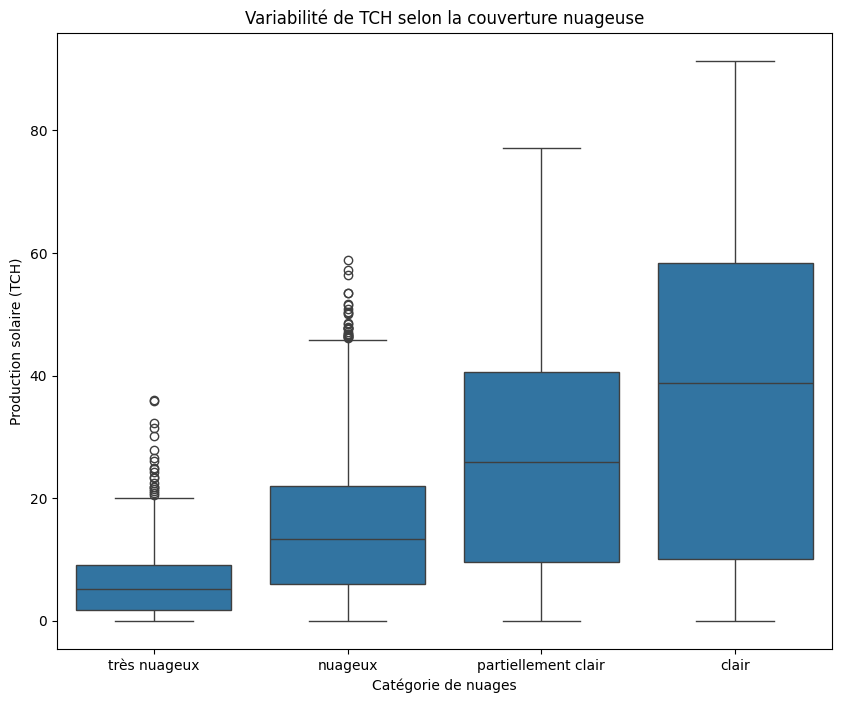

In [25]:
bins = [0, 0.2, 0.5, 0.8, 1]
labels = ['très nuageux', 'nuageux', 'partiellement clair', 'clair']
df_day["CSI"] = df_day["region_ghi"] / df_day["region_clear_sky_ghi"]
df_day['cloud_category_CSI'] = pd.cut(df_day['CSI'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(10,8))
sns.boxplot(x='cloud_category_CSI', y='tch_solaire', data=df_day)
plt.xlabel('Catégorie de nuages')
plt.ylabel('Production solaire (TCH)')
plt.title('Variabilité de TCH selon la couverture nuageuse')
plt.show()

**Comparaison entre nébulosité observée et nébulosité radiative**

L'analyse basée sur l'indice de ciel clair (CSI) met en évidence un **comportement globalement identique** à celui observé précédemment avec la nébulosité régionale exprimée en pourcentage.

Dans les deux approches, la production solaire (TCH) :
- diminue progressivement lorsque la couverture nuageuse augmente,
- devient plus faible et plus homogène sous des conditions fortement nuageuses.

Cette cohérence entre les deux classifications confirme que la **variabilité de TCH est principalement gouvernée par l'atténuation radiative induite par les nuages**, et non uniquement par leur présence apparente. L'utilisation du CSI permet toutefois une interprétation plus directement liée aux mécanismes physiques de réduction de l'irradiance, renforçant ainsi la robustesse de l'analyse.


### 2 - Lecture par *régimes de ciel* : classes de **GHI**

Le **GHI** est une **variable intégratrice** qui “voit” à la fois :
- la géométrie solaire (cycle journalier / saison),
- et surtout l'**atténuation nuageuse**, qui crée la **variabilité** (jours clairs vs jours perturbés).

On segmente donc les journées en **classes de GHI** (faible → fort) afin de comparer, *à régime comparable*, la dispersion de la production (**TCH**) et des composantes radiatives (BNI/BHI/DHI).

**Étape 1 — Définir les bornes de GHI**

- *faible GHI* : jours très nuageux / atténuation forte,
- *GHI intermédiaire* : ciel variable,
- *fort GHI* : jours clairs (variabilité faible).


**Étape 2 — Comparer la dispersion (variabilité) par régime**

Pour chaque classe de GHI, on regarde comment la production et/ou les composantes radiatives se distribuent.
Visuellement, si le **GHI** est bien le “moteur” de variabilité, on doit observer :
- une **dispersion plus large** quand le GHI est faible/intermédiaire,
- une **dispersion resserrée** quand le GHI est élevé (jours clairs).

/tmp/ipykernel_9756/3310768528.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['GHI_bin2'] = pd.cut(
/tmp/ipykernel_9756/3310768528.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


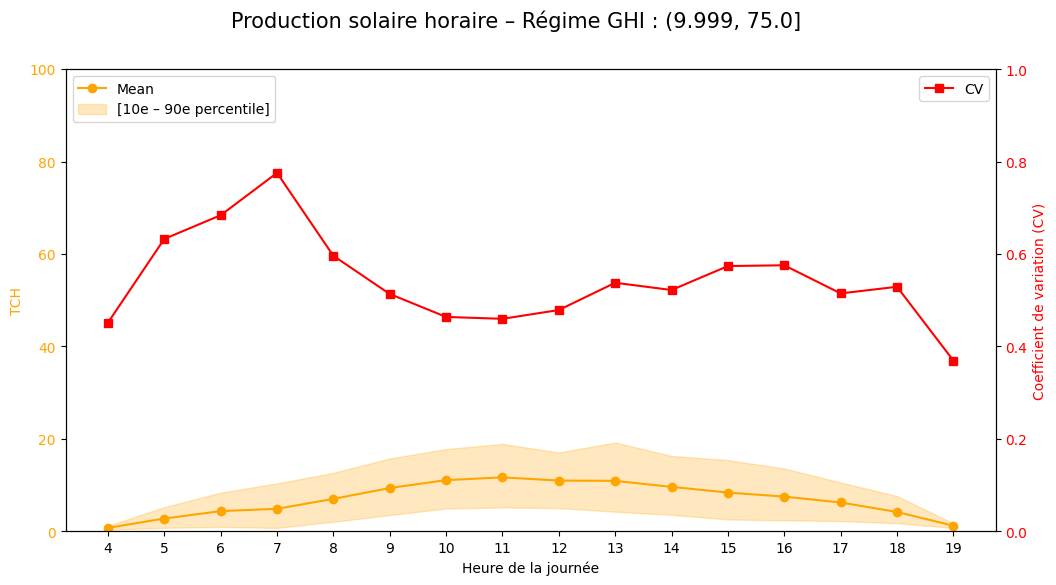

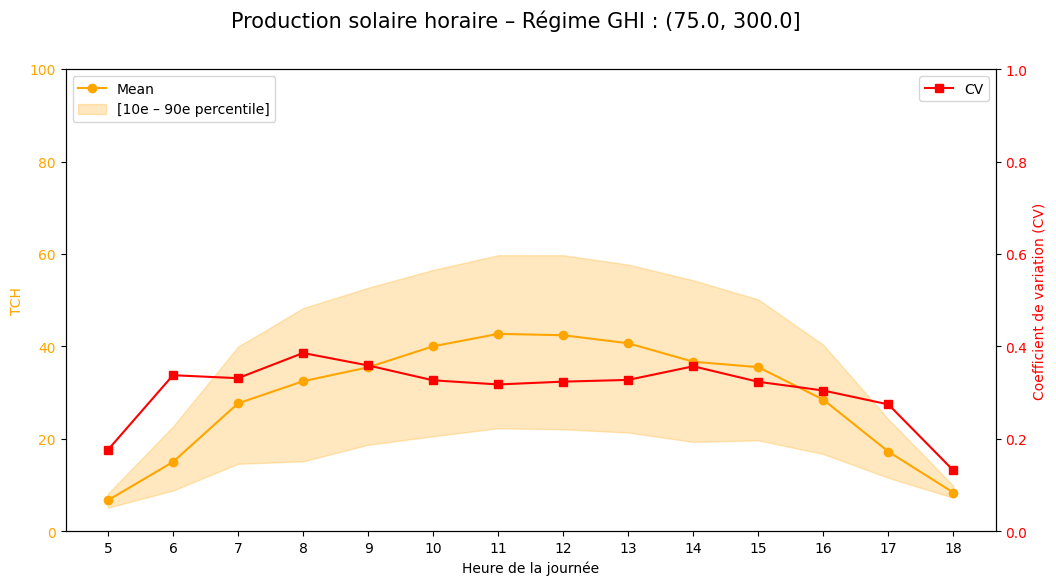

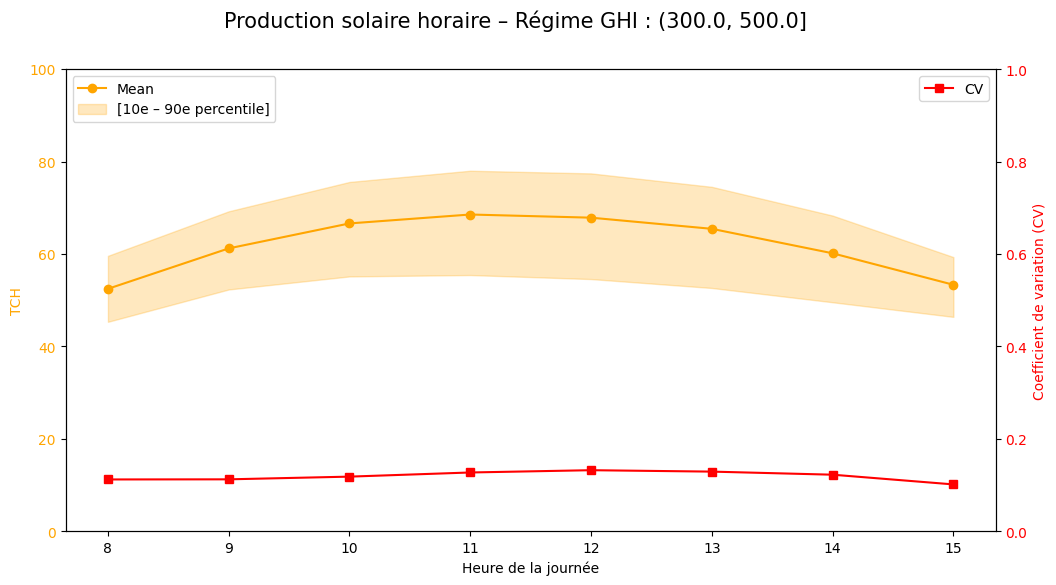

In [26]:
bins = [10, 75, 300, 500]

df_day['GHI_bin2'] = pd.cut(
    df_day['region_ghi'],
    bins=bins,
    include_lowest=True
)


for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    hour_stats = df_bin.groupby('hour')['tch_solaire'].describe()
    hour_stats['cv'] = hour_stats['std'] / hour_stats['mean']

    # Percentiles
    hour_stats['p10'] = df_bin.groupby('hour')['tch_solaire'].quantile(0.10)
    hour_stats['p90'] = df_bin.groupby('hour')['tch_solaire'].quantile(0.90)
    # display(hour_stats)
    
    heures = hour_stats.index
    mean = hour_stats['mean']
    cv = hour_stats['cv']
    p10 = hour_stats['p10']
    p90 = hour_stats['p90']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(heures, mean, marker='o', color='orange', label='Mean')
    ax1.fill_between(heures, p10, p90, color='orange', alpha=0.25,
                     label='[10e – 90e percentile]')
    ax1.set_xlabel('Heure de la journée')
    ax1.set_ylabel('TCH', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(heures)

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(heures, cv, marker='s', color='red', label='CV')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Coefficient de variation (CV)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Titre et légendes
    fig.suptitle(
        f'Production solaire horaire – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


/tmp/ipykernel_9756/2708908920.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


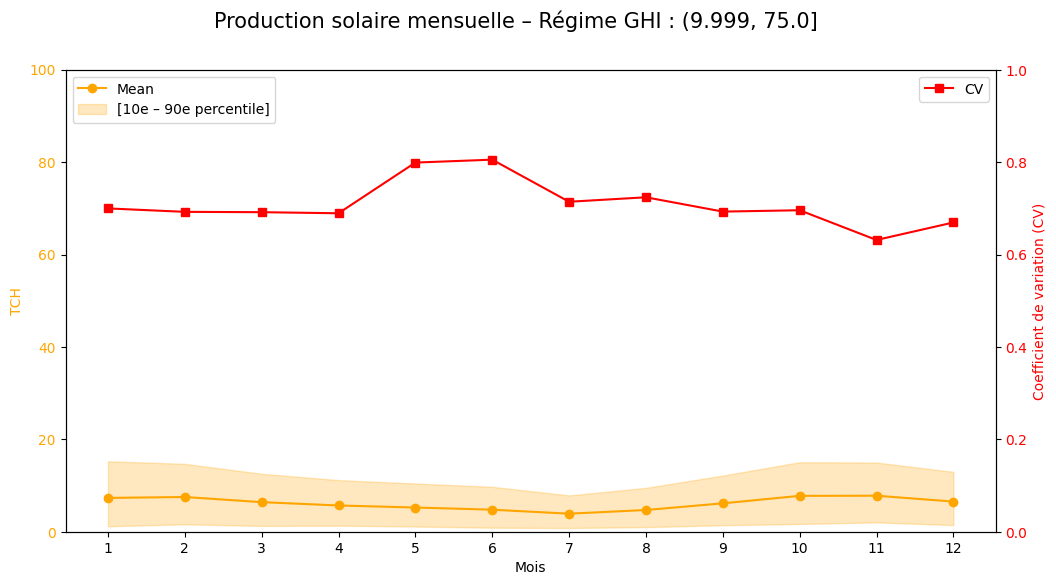

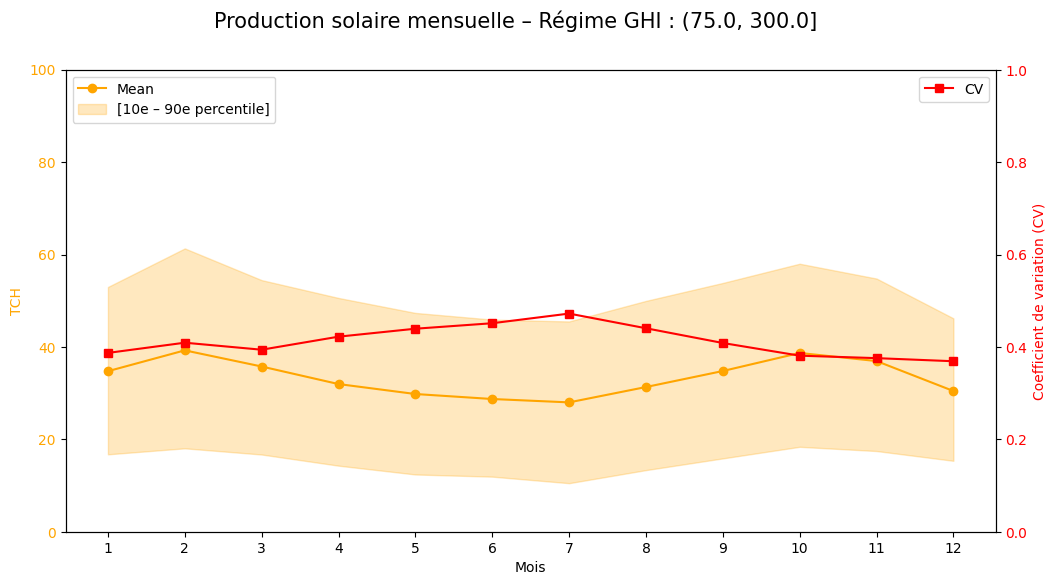

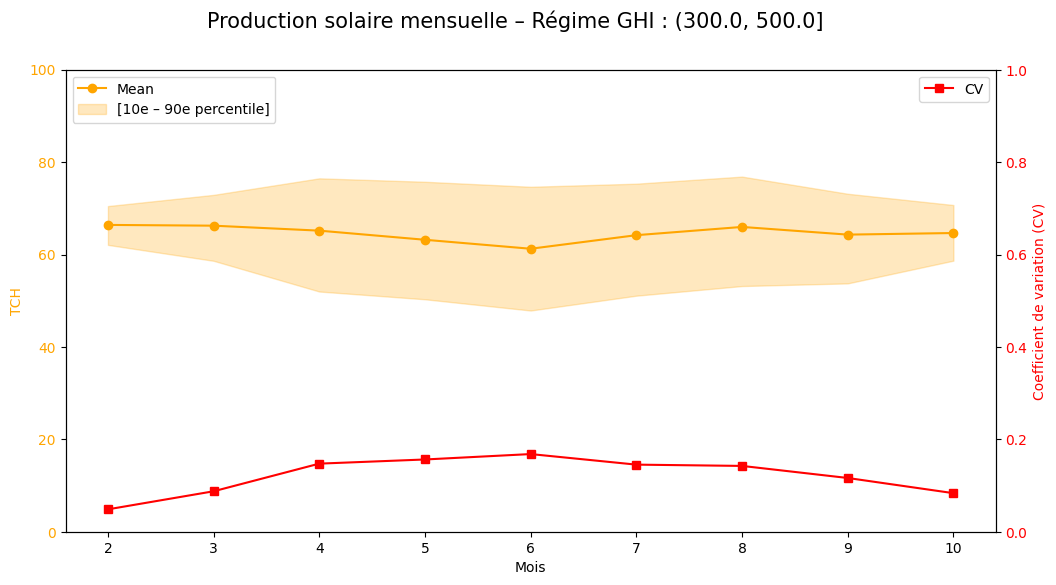

In [27]:
for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    month_stats = df_bin.groupby('month')['tch_solaire'].describe()
    month_stats['cv'] = month_stats['std'] / month_stats['mean']

    # Percentiles
    month_stats['p10'] = df_bin.groupby('month')['tch_solaire'].quantile(0.10)
    month_stats['p90'] = df_bin.groupby('month')['tch_solaire'].quantile(0.90)

    mois = month_stats.index
    mean = month_stats['mean']
    cv = month_stats['cv']
    p10 = month_stats['p10']
    p90 = month_stats['p90']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(mois, mean, marker='o', color='orange', label='Mean')
    ax1.fill_between(mois, p10, p90, color='orange', alpha=0.25,
                     label='[10e – 90e percentile]')
    ax1.set_xlabel('Mois')
    ax1.set_ylabel('TCH', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(mois)

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(mois, cv, marker='s', color='red', label='CV')
    ax2.set_ylim(0,1)
    ax2.set_ylabel('Coefficient de variation (CV)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Titre et légendes
    fig.suptitle(
        f'Production solaire mensuelle – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


/tmp/ipykernel_9756/2377919455.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_day['doy'] = df_day.index.dayofyear
/tmp/ipykernel_9756/2377919455.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):


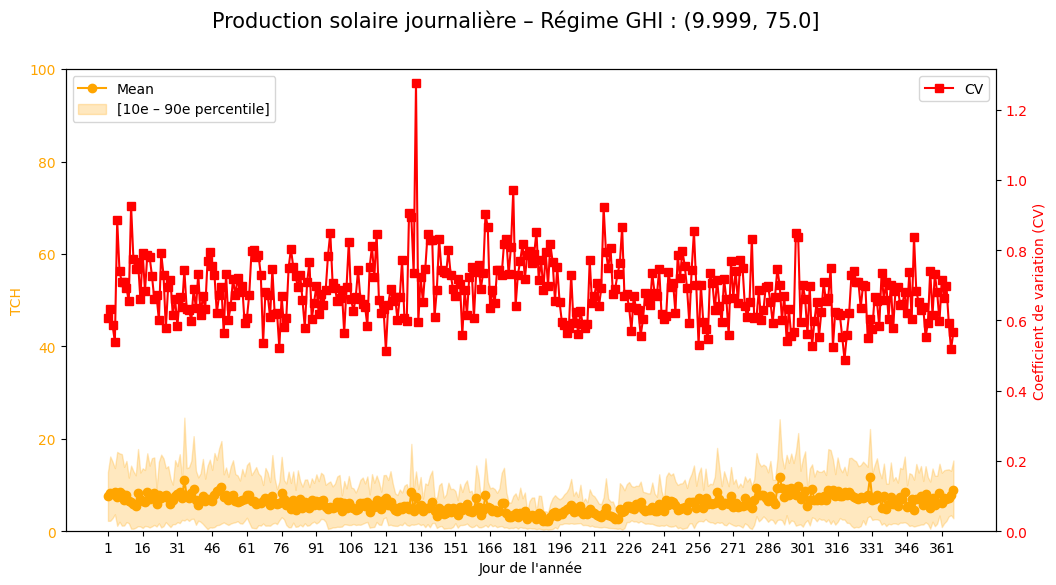

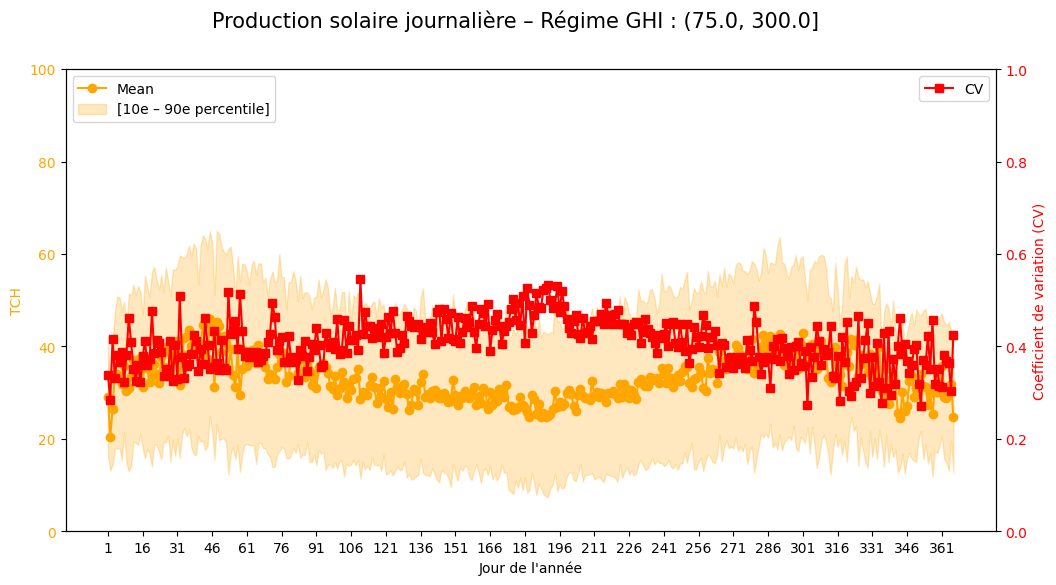

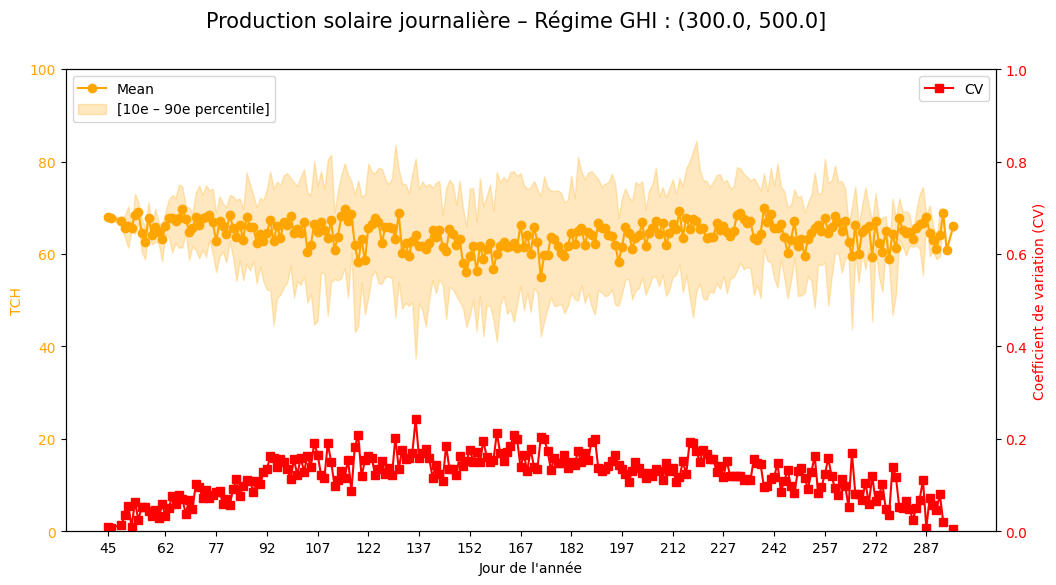

In [28]:
df_day['doy'] = df_day.index.dayofyear
for ghi_bin, df_bin in df_day.groupby('GHI_bin2'):

    # Statistiques horaires
    jour_stats = df_bin.groupby('doy')['tch_solaire'].describe()
    jour_stats['cv'] = jour_stats['std'] / jour_stats['mean']

    # Percentiles
    jour_stats['p10'] = df_bin.groupby('doy')['tch_solaire'].quantile(0.10)
    jour_stats['p90'] = df_bin.groupby('doy')['tch_solaire'].quantile(0.90)

    jours = jour_stats.index
    mean = jour_stats['mean']
    cv = jour_stats['cv']
    p10 = jour_stats['p10']
    p90 = jour_stats['p90']

    # Figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Moyenne + bande P10–P90
    ax1.plot(jours, mean, marker='o', color='orange', label='Mean')
    ax1.fill_between(jours, p10, p90, color='orange', alpha=0.25,
                     label='[10e – 90e percentile]')
    ax1.set_xlabel("Jour de l'année")
    ax1.set_ylabel('TCH', color='orange')
    ax1.tick_params(axis='y', labelcolor='orange')
    ax1.set_ylim(0, 100)
    ax1.set_xticks(jours[::15])

    # Axe secondaire : CV
    ax2 = ax1.twinx()
    ax2.plot(jours, cv, marker='s', color='red', label='CV')
    ax2.set_ylim(0, max(ax2.get_ylim()[1], 1))
    ax2.set_ylabel('Coefficient de variation (CV)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Titre et légendes
    fig.suptitle(
        f'Production solaire journalière – Régime GHI : {ghi_bin}',
        fontsize=15
    )
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()


## D - Conclusion : pourquoi le **GHI** porte l'essentiel de la variabilité

Les figures par **régime de GHI** montrent une lecture très claire :

- Quand le **GHI est faible** (journées nuageuses / diffus), la production **TCH** devient **plus instable** : la bande *P10–P90* s'élargit et le **CV** (variabilité relative) augmente.
- Quand le **GHI est élevé** (journées dégagées), la production est **plus régulière** : la dispersion se resserre et le **CV** diminue.

Autrement dit, **le GHI est la variable qui “déclenche” la variabilité** observée dans la production : il capte à la fois l'intensité du rayonnement reçu et, indirectement, l'état du ciel (clair vs couvert) qui gouverne la fluctuation.